# Connectivity

In [ ]:
import pandas as pd
import numpy as np
import json
import os
import seaborn as sns
import matplotlib.pyplot as plt
import networkx as nx
from scipy.stats import ttest_ind

from utils import OUT_PATH, GetInfo, ExcludSubj, COL_REG

tfr_path = OUT_PATH+ '/Data_longWOBS'
subj_included = [file.replace('_TFRtrials.p', '') for file in os.listdir(tfr_path) if file[-len('TFRtrials.p'):] == 'TFRtrials.p']
subj_included = ExcludSubj(subj_included, data_path=tfr_path)
print(f"Subject Nbr is {len(subj_included)}")

path = tfr_path + f'/{subj_included[0]}_info.json'
with open(path) as json_data:
    d = json.load(json_data)
    time_tfr=d['time_tfr']
     
_, areas, _, subj_list, regions = GetInfo(subj_included, data_path=tfr_path)

Subject Nbr is 30


In [3]:
switch = {'compo2' : [(15, 73), (73, 131)],  'compo3' : [(25, 67), (67, 109)]}

In [7]:
# import data
events = ['old/correct', 'new/correct']
band = 'high_gamma'
pc='compo3'
weight = pd.read_csv(OUT_PATH + '/grpPCA/supsubj_concat/grp_concat_Compo_PCA5.csv').query('freq == @band & compo == @pc').drop(columns = ['Unnamed: 0', 'freq', 'compo']).values[0, :]
data_ch = pd.DataFrame()
data_ch['ch1'] = np.where(abs(weight) > abs(weight).mean() + abs(weight).std(), True, False)
data_ch['subj'] = subj_list
data_ch['ROIs'] = [a[0] for a in areas] #regions
rois = data_ch[data_ch['ch1'] == True]['ROIs'].values
method= 'aec'

con_old_all = pd.read_csv(OUT_PATH + f'/Connectivity_area/{band}/{method}_{pc}_{events[0][:3]}_all.csv').set_index('rois')
con_old_1 = pd.read_csv(OUT_PATH + f'/Connectivity_area/{band}/{method}_{pc}_{events[0][:3]}_25_67.csv').set_index('rois')
con_old_2 = pd.read_csv(OUT_PATH + f'/Connectivity_area/{band}/{method}_{pc}_{events[0][:3]}_67_109.csv').set_index('rois')

con_new = pd.read_csv(OUT_PATH + f'/Connectivity_area/{band}/{method}_{pc}_{events[1][:3]}_all.csv').set_index('rois')
con_new_1 = pd.read_csv(OUT_PATH + f'/Connectivity_area/{band}/{method}_{pc}_{events[1][:3]}_25_67.csv').set_index('rois')
con_new_2 = pd.read_csv(OUT_PATH + f'/Connectivity_area/{band}/{method}_{pc}_{events[1][:3]}_67_109.csv').set_index('rois')

Text(0.5, 1.0, 'After')

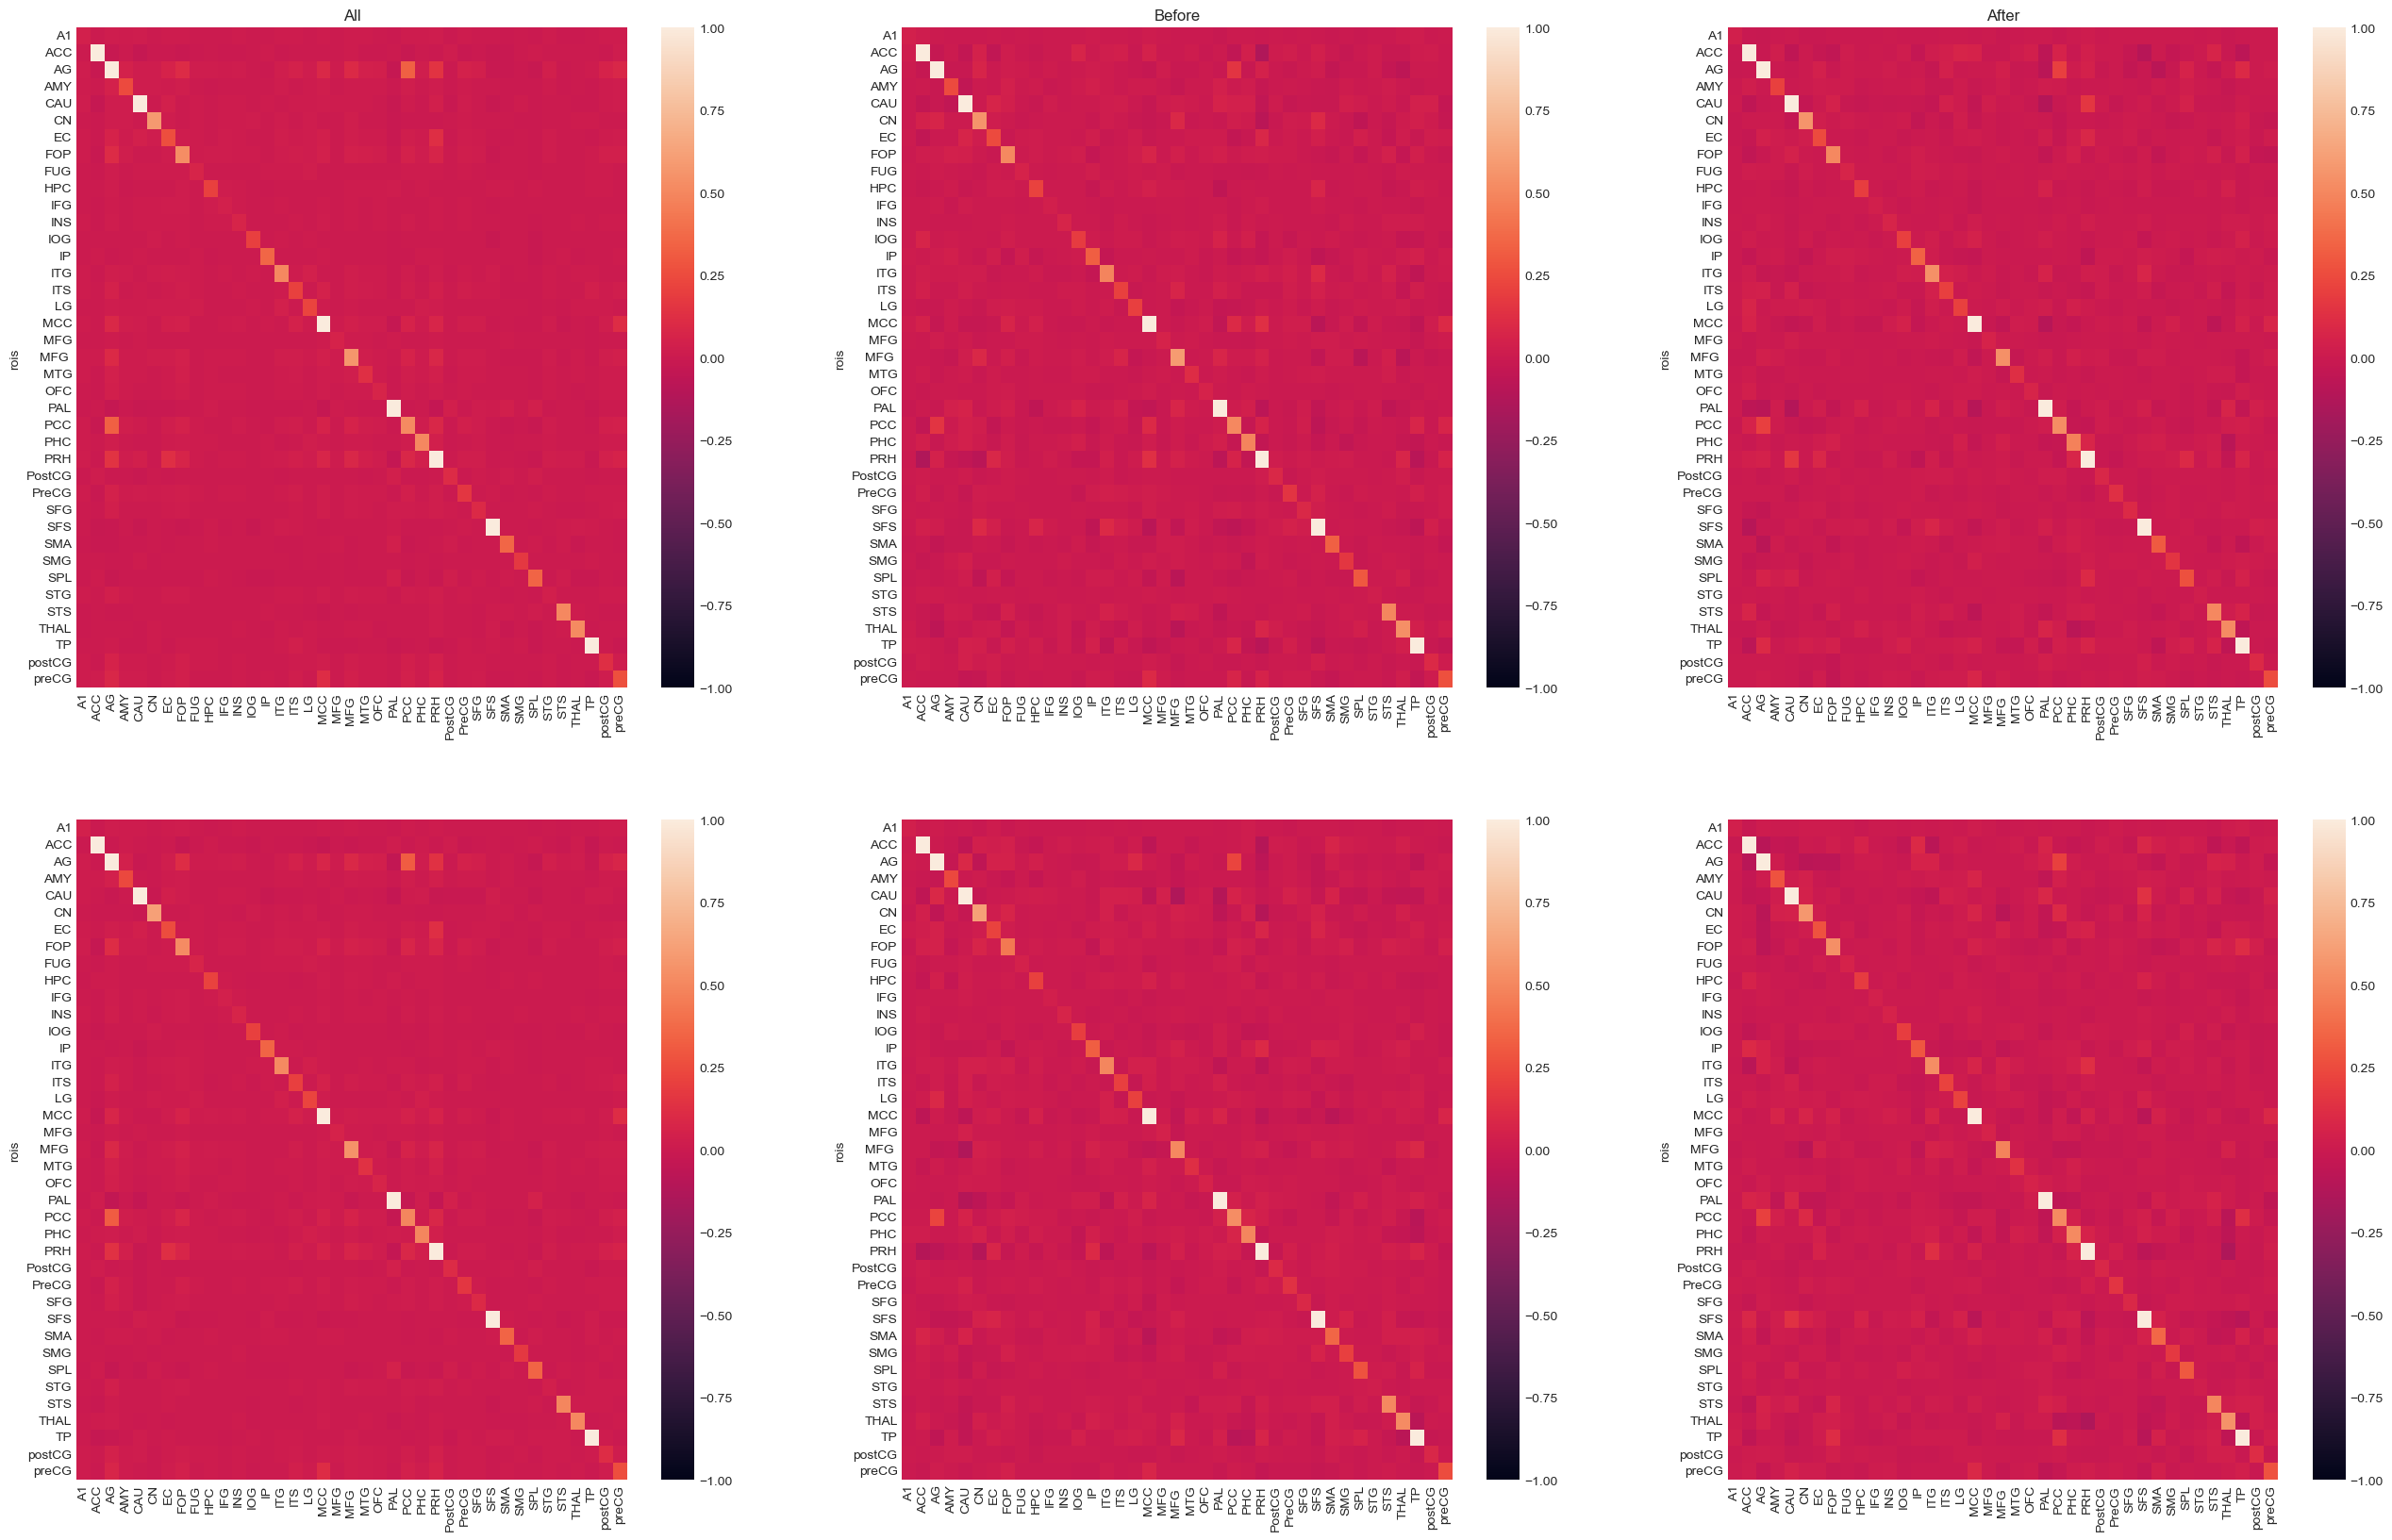

In [8]:

fig, ax = plt.subplots(2, 3, figsize = (32, 20))
vmin=-1
vmax = 1
sns.heatmap(con_old_all, ax=ax[0][0], vmin=vmin, vmax = vmax)
sns.heatmap(con_old_1, ax=ax[0][1],  vmin=vmin, vmax = vmax)
sns.heatmap(con_old_2, ax=ax[0][2],  vmin=vmin, vmax = vmax)

sns.heatmap(con_new, ax=ax[1][0],  vmin=vmin, vmax = vmax)
sns.heatmap(con_new_1, ax=ax[1][1],  vmin=vmin, vmax = vmax)
sns.heatmap(con_new_2, ax=ax[1][2],  vmin=vmin, vmax = vmax)

ax[0][0].set_title('All')
ax[0][1].set_title('Before')
ax[0][2].set_title('After')


In [24]:
from scipy.stats import ttest_ind

/opt/anaconda3/envs/MEGEEG/lib/python3.12/site-packages/scipy/stats/_stats_py.py:6316: RuntimeWarning: invalid value encountered in scalar divide
  svar = ((n1 - 1) * v1 + (n2 - 1) * v2) / df
/opt/anaconda3/envs/MEGEEG/lib/python3.12/site-packages/scipy/stats/_stats_py.py:6316: RuntimeWarning: invalid value encountered in scalar divide
  svar = ((n1 - 1) * v1 + (n2 - 1) * v2) / df
/opt/anaconda3/envs/MEGEEG/lib/python3.12/site-packages/scipy/stats/_stats_py.py:6316: RuntimeWarning: invalid value encountered in scalar divide
  svar = ((n1 - 1) * v1 + (n2 - 1) * v2) / df
/opt/anaconda3/envs/MEGEEG/lib/python3.12/site-packages/scipy/stats/_stats_py.py:6316: RuntimeWarning: invalid value encountered in scalar divide
  svar = ((n1 - 1) * v1 + (n2 - 1) * v2) / df
/opt/anaconda3/envs/MEGEEG/lib/python3.12/site-packages/scipy/stats/_stats_py.py:6316: RuntimeWarning: invalid value encountered in scalar divide
  svar = ((n1 - 1) * v1 + (n2 - 1) * v2) / df
/opt/anaconda3/envs/MEGEEG/lib/python3.1

<Axes: >

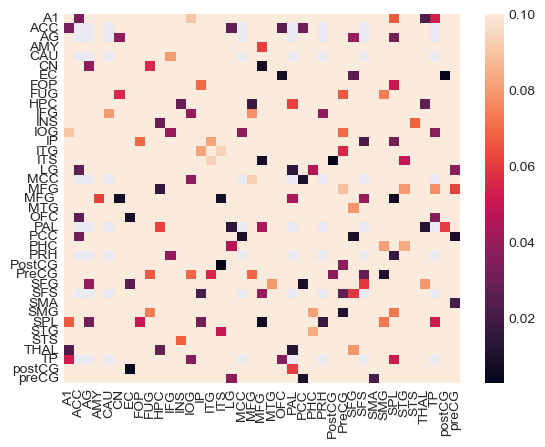

In [ ]:
con_old_1 = pd.read_csv(OUT_PATH + f'/Connectivity_area/{band}/{method}_{pc}_{events[0][:3]}_25_67_ch.csv').set_index('rois')
con_new_1 = pd.read_csv(OUT_PATH + f'/Connectivity_area/{band}/{method}_{pc}_{events[0][:3]}_67_109_ch.csv').set_index('rois')

stat_roi = np.zeros([len(np.unique(rois)), len(np.unique(rois))])
for i, r1 in enumerate(np.unique(rois)) :
    for j, r2 in enumerate(np.unique(rois)) :
        sub_old = con_old_1.loc[r1, [col for col in con_old_1.columns if r2 in col]].values.flatten()
        sub_new = con_new_1.loc[r1, [col for col in con_new_1.columns if r2 in col]].values.flatten()
        #stat_roi[i, j] = ttest_ind(sub_old, sub_new).pvalue

#sns.heatmap(stat_roi, vmax=0.1, xticklabels=np.unique(rois), yticklabels=np.unique(rois))



### granger significance

In [ ]:
granger_old = pd.read_csv(OUT_PATH + f'/Connectivity_area/{band}/{method}_{pc}_{events[0][:3]}_25_67_ch.csv').set_index('rois')

#from scipy.stats import f
#p_value = 1 - f.cdf(Fval, df1, df2)


granger_old[abs(granger_old)>=1]

,IFG,IFG.1,FUG,ITS,SMG,SMG.1,SMG.2,STS,STG,STG.1,...,A1.31,A1.32,MTG.8,INS.15,SFS,PHC.1,FUG.18,OFC.18,INS.16,STG.37
rois,,,,,,,,,,,,,,,,,,,,,
IFG,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
IFG,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
FUG,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ITS,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SMG,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
PHC,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN
FUG,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OFC,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN


## Graph

In [18]:
# set the metric a link of the network 
G = nx.Graph()
G.add_nodes_from(rois)

for i, r1 in enumerate(rois):
    for j in range(i+1, len(rois)):
        if i == j : continue
        r2 = rois[j]
        weight = con_old_all.loc[r1, r2]
        G.add_edge(r1, r2, weight=weight)

## With Mutual info -- don't work too small sample even lumping the Rois elect

In [75]:
from sklearn.neighbors import NearestNeighbors
from scipy.special import digamma

# k The number of nearest neighbors used to estimate local probability density around each sample point.
def kraskov_mi(x, y, k=5):
    xy = np.column_stack((x, y))
    n = len(x)

    nbrs = NearestNeighbors(n_neighbors=k+1, metric='chebyshev')
    nbrs.fit(xy)
    distances, _ = nbrs.kneighbors(xy)
    eps = distances[:, k]  

    nx = []
    ny = []

    for i in range(n):
        nx.append(np.sum(np.abs(x - x[i]) < eps[i]) - 1)
        ny.append(np.sum(np.abs(y - y[i]) < eps[i]) - 1)

    nx = np.array(nx)
    ny = np.array(ny)

    mi = digamma(k) + digamma(n) - np.mean(digamma(nx+1) + digamma(ny+1))
    return mi


In [76]:
# first time window : before switch
data_b = {ev:[] for ev in events}
for ev in events :
    for tr in trials[ev] : 
        data_b[ev].extend([tr[:,c, 0,25:switch_id] for c in range(tr.shape[1])])


In [77]:
# concat all the electrods of the same area to use mi
data_b_r = {ev:{r: [] for r in regions} for ev in events}

for ev in events :
    min_ = []
    d_r = {r: [] for r in regions} 
    for r in np.unique(regions) :
        id_ = data_ch[data_ch['ch1'] == True].reset_index()[data_ch['ROIs'] == r].index.values
        if len(id_) == 0 : 
            min_.append(0)
            continue
        for i in id_ : 
            d_r[r].append(data_b[ev][i])

        min_.append(np.min([len(d_r[r][i]) for i in range(len(d_r[r]))]))

    for ir, r in enumerate(np.unique(regions)) :
        id_ = data_ch[data_ch['ch1'] == True].reset_index()[data_ch['ROIs'] == r].index.values
        l = [d_r[r][i][:min_[ir]] for i in range(len(d_r[r])) if min_[ir] != 0]
        if len(l) != 0 :
            data_b_r[ev][r] = np.vstack(l)

/var/folders/rr/sx7rgrrj3p12hz70crvxqcjc0000gn/T/ipykernel_4370/2514667255.py:8: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  id_ = data_ch[data_ch['ch1'] == True].reset_index()[data_ch['ROIs'] == r].index.values
/var/folders/rr/sx7rgrrj3p12hz70crvxqcjc0000gn/T/ipykernel_4370/2514667255.py:8: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  id_ = data_ch[data_ch['ch1'] == True].reset_index()[data_ch['ROIs'] == r].index.values
/var/folders/rr/sx7rgrrj3p12hz70crvxqcjc0000gn/T/ipykernel_4370/2514667255.py:8: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  id_ = data_ch[data_ch['ch1'] == True].reset_index()[data_ch['ROIs'] == r].index.values
/var/folders/rr/sx7rgrrj3p12hz70crvxqcjc0000gn/T/ipykernel_4370/2514667255.py:8: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  id_ = data_ch[data_ch['ch1'] == True].reset_index()[data_ch['ROIs'] == r].index.values
/var/folders/rr/

In [82]:
# at Rois level
Mi_b = np.zeros([len(data_b_r['old/correct']), len(data_b_r['old/correct'])])

for k in [1, 2, 3, 4] :
    for i,items_x in enumerate(data_b_r['old/correct'].items()):
        xk, xv= items_x
        if len(xv) == 0 :
            continue

        for j,items_y in enumerate(data_b_r['old/correct'].items()) :
            yk, yv= items_y
            if len(yv) == 0 :
                continue
            min_trial = np.min([xv.shape[0], yv.shape[0]])
            
            Mi_b[i, j] = kraskov_mi(xv[:min_trial, :], yv[:min_trial, :], k=k)
    
    print(np.min(Mi_b), np.max(Mi_b))


-14.057431094112868 0.0
-13.123090717732214 0.0
-12.652577306626188 0.0
-12.339663171533523 0.0


In [62]:
# first time window : before switch
data_a = {ev:[] for ev in events}
for ev in events :
    for tr in trials[ev] : 
        data_a[ev].extend([tr[:,c, 0,switch_id:120] for c in range(tr.shape[1])])

Mi_a = np.zeros([len(data_a['old/correct']), len(data_a['old/correct'])])
for i,x in enumerate(data_a['old/correct']):
    for j,y in enumerate(data_a['old/correct']) :
        min_trial = np.min([x.shape[0], y.shape[0]])
        Mi_a[i, j] = kraskov_mi(x[:min_trial, :], y[:min_trial, :], k=5)



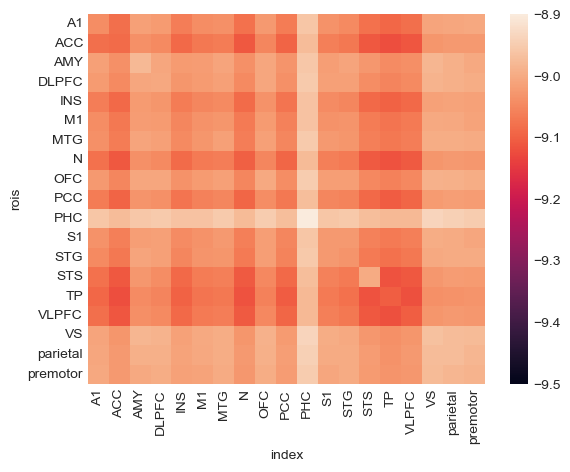

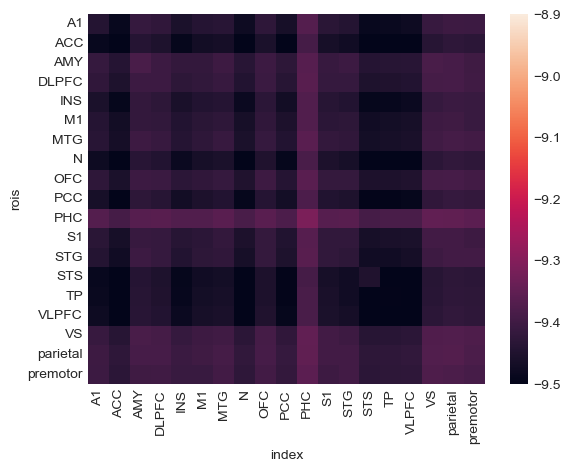

In [65]:
rois = data_ch[data_ch['ch1'] == True]['ROIs'].values

for mi in [Mi_b, Mi_a] : 
    df_Mi = pd.DataFrame(mi, columns = rois)
    df_Mi['rois'] = rois
    df_Mi= df_Mi.set_index('rois')
    df_Mi = df_Mi.reset_index().groupby('rois').mean().T.reset_index().groupby('index').mean().T

    sns.heatmap(df_Mi, vmin= -9.5, vmax = -8.9)
    plt.show()